## EJERCICIO PRACTICO CLASE 3

GRUPO 4 - INTEGRANTES
- DARIO WLADIMIR HERRERA CHÁVEZ
- SANTIAGO PAUL GUALLICHICO ATI
- ROBINSON  DAMIAN CHILUISA GALLARDO

## 1. Descripcion del Trabajo
Utilice el dataset de cáncer de mama (Diagnostic Wisconsin Breast Cancer Database, WBCD) donde tenemos los datos de 569 mujeres. Cada mujer está descrita por 32 atributos. El primero es un identificador, el segundo el tipo de cáncer (Maligno o Benigno) y el resto son características numéricas extraídas de imágenes de biopsias de tejido mamario. Se pretende aprender el tipo de cáncer de mama (maligno=1, benigno=0), utilizando previamente el algoritmo PCA para reducción de dimensiones. Luego se realiza un agrupamiento (clustering) usando K-Means y Gaussian Mixture Models (GMM), comparando los clústeres obtenidos con los componentes principales de PCA y con las clases reales del dataset. En este conjunto de datos la distribución de clases es: 357 benignos y 212 malignos.

Este trabajo se desarrolla en dos fases: la Fase I aborda la reducción de dimensiones con PCA y la clasificación supervisada (con y sin PCA); la Fase II aborda el agrupamiento no supervisado, comparando K-Means y GMM con distintos números de clústeres (K=2 y K=3).

### 1.1 Modelos de clasificación evaluados con PCA=2

Se evaluaron los siguientes algoritmos de clasificación supervisada:

- LR: Regresión Logística
- K-NN: K-Nearest Neighbors
- NB: Naive Bayes
- DT: Árbol de Decisión
- RF: Random Forest
- ANN: Red Neuronal Artificial (MLP)
- SVM: Support Vector Machine


## 2. Objetivo y alcance del trabajo
Esta práctica tiene el objetivo de realizar la predicción del tipo de cáncer de mama (maligno=1, benigno=0) utilizando el algoritmo de reducción de dimensiones PCA y los algoritmos de clasificación supervisada revisados anteriormente, así como realizar tareas de agrupamiento (clustering) con K-Means y GMM, evaluando ambos enfoques mediante las métricas y gráficas de rendimiento correspondientes. Al finalizar la práctica, los maestrantes podrán entender el impacto de usar PCA en el dataset, así como comparar la calidad del agrupamiento obtenido por distintos algoritmos no supervisados y distintos números de clústeres.

## 3. Desarrollo del trabajo

### 3.1 Importación de Liberias y metricas 

Se realiza la importación de las librerías y métricas necesarias para el desarrollo del modelo de machine learning, incluyendo herramientas para manipulación de datos, preprocesamiento, reducción de dimensionalidad, entrenamiento de algoritmos de clasificación y evaluación del desempeño mediante diferentes métricas.

In [1]:
# =========================================
# 3.1. IMPORTACIÓN DE LIBRERÍAS Y METRICAS
# =========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# IMPORTACIÓN DE MÉTRICAS
# =========================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

### 3.2 Carga del Dataset

Se realiza la carga del dataset de cáncer de mama utilizando la función load_breast_cancer(). Posteriormente, se separan las variables independientes (X), que contienen las características del conjunto de datos, y la variable dependiente (y), que representa las clases objetivo (0 = maligno, 1 = benigno), para su uso en el entrenamiento del modelo de clasificación.

In [2]:
# =========================================
# 3.2. CARGA DEL DATASET
# =========================================

data = load_breast_cancer()
X = data.data
y = data.target  # 0 = Maligno | 1 = Benigno

### 3.3 Train /Test Split

Se realiza la división del dataset en conjuntos de entrenamiento y prueba utilizando train_test_split. El 80% de los datos se asigna al entrenamiento y el 20% al test, asegurando una partición estratificada según la variable objetivo (stratify=y) para mantener la proporción de clases. Además, se establece un random_state para garantizar la reproducibilidad de los resultados

In [3]:
# =========================================
# 3.3. TRAIN / TEST SPLIT
# =========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 3.4 Escalado de Datos

Se realiza el escalado de los datos utilizando StandardScaler, con el objetivo de estandarizar las variables del conjunto de datos. Primero se ajusta el escalador con los datos de entrenamiento (fit_transform) y luego se aplica la misma transformación al conjunto de prueba (transform), garantizando que ambos queden en la misma escala para mejorar el rendimiento de los modelos de machine learning.

In [4]:
# =========================================
# 3.4. ESCALADO DE DATOS
# =========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.5 PCA = 2 componentes

Se aplica el análisis de componentes principales (PCA) con el objetivo de reducir la dimensionalidad de los datos a 2 componentes principales. Primero se ajusta el modelo con el conjunto de entrenamiento escalado (fit_transform) y luego se transforma el conjunto de prueba (transform), permitiendo conservar la mayor cantidad de información posible en menos variables para facilitar la visualización y el entrenamiento de los modelos.

In [5]:
# =========================================
# 3.5. PCA (2 COMPONENTES)
# =========================================

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### 3.6 Visualizacion PCA

Se realiza la visualización del conjunto de entrenamiento después de aplicar PCA con 2 componentes principales. Los datos se separan según su clase (maligno y benigno) y se representan en un gráfico de dispersión, donde cada punto corresponde a una muestra proyectada en el espacio reducido. Esto permite observar de forma visual la distribución de las clases y su posible separabilidad en las dos dimensiones principales

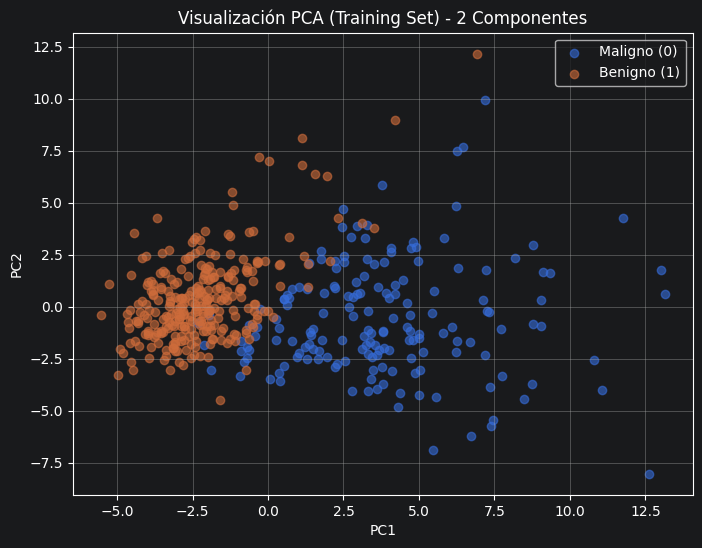

In [6]:
# =========================================
# 3.6. VISUALIZACIÓN PCA (TRAINING SET)
# =========================================

X_maligno = X_train_pca[y_train == 0]
X_benigno = X_train_pca[y_train == 1]

plt.figure(figsize=(8, 6))
plt.scatter(X_maligno[:, 0], X_maligno[:, 1], alpha=0.6, label="Maligno (0)")
plt.scatter(X_benigno[:, 0], X_benigno[:, 1], alpha=0.6, label="Benigno (1)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualización PCA (Training Set) - 2 Componentes")
plt.legend()
plt.grid(True)
plt.show()

### 3.7  Definicion de los Modelos

Se definen distintos modelos de clasificación supervisada que serán utilizados para el análisis del dataset. Se incluyen algoritmos como Regresión Logística, K-Nearest Neighbors, Naive Bayes, Árboles de Decisión, Random Forest, Redes Neuronales (MLP) y Support Vector Machine (SVM). Todos los modelos se almacenan en un diccionario para facilitar su entrenamiento, evaluación y comparación posterior.

In [7]:
# =========================================
# 3.7. DEFINICIÓN DE MODELOS
# =========================================

modelos = {
    "LR": LogisticRegression(max_iter=1000),
    "K-NN": KNeighborsClassifier(n_neighbors=5),
    "NB": GaussianNB(),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=100, random_state=42),
    "ANN": MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf")
}

###  3.8 Evaluacion de metricas

Se realiza el entrenamiento y evaluación de múltiples modelos de clasificación definidos previamente. Para cada modelo se ajusta el entrenamiento con los datos escalados, se realizan predicciones sobre el conjunto de prueba y, en caso de ser posible, se calculan probabilidades para obtener el área bajo la curva ROC (AUC).

Posteriormente, se calculan diferentes métricas de desempeño como accuracy, precision, recall y F1-score. Todos los resultados se almacenan en una lista y finalmente se organizan en una tabla para comparar el rendimiento de cada modelo en el conjunto de prueba.

In [8]:
# =========================================
# 3.8 MÉTRICAS PARA CADA MODELO
# =========================================

metricas = []

for nombre, modelo in modelos.items():

    # ---- Entrenar modelo ----
    modelo.fit(X_train_scaled, y_train)

    # ---- Predicciones ----
    y_pred = modelo.predict(X_test_scaled)

    # ---- Probabilidades (para ROC AUC) ----
    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan  # algunos modelos no soportan predict_proba

    # ---- Métricas ----
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    metricas.append([
        nombre,
        round(acc, 3),
        round(prec, 3),
        round(rec, 3),
        round(f1, 3),
        round(auc, 3) if not np.isnan(auc) else "N/A"
    ])

# =========================================
# TABLA FINAL DE MÉTRICAS
# =========================================

df_metricas = pd.DataFrame(
    metricas,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC AUC"
    ]
)

print("\nMÉTRICAS POR MODELO (TEST SET)\n")
print(df_metricas)


MÉTRICAS POR MODELO (TEST SET)

  Modelo  Accuracy  Precision  Recall  F1-score ROC AUC
0     LR     0.982      0.986   0.986     0.986   0.995
1   K-NN     0.956      0.959   0.972     0.966   0.979
2     NB     0.930      0.944   0.944     0.944   0.987
3     DT     0.912      0.956   0.903     0.929   0.916
4     RF     0.956      0.959   0.972     0.966   0.994
5    ANN     0.956      0.986   0.944     0.965   0.994
6    SVM     0.982      0.986   0.986     0.986     N/A


### 3.9 Entrenamiento y Evaluacion

Se realiza el entrenamiento y evaluación de los modelos de clasificación tanto sin reducción de dimensionalidad como utilizando PCA con 2 componentes. Para cada modelo, se entrena primero con los datos escalados originales y luego con los datos reducidos mediante PCA, calculando la exactitud (accuracy) en ambos casos.

Además, se guardan los modelos entrenados en archivos .pkl utilizando joblib, y se registra el tamaño de cada modelo en memoria. Finalmente, los resultados de rendimiento y tamaño de los modelos se almacenan en una lista para su posterior análisis y comparación.

In [9]:
# =========================================
# 3.9. ENTRENAMIENTO Y EVALUACIÓN
# =========================================

resultados = []
os.makedirs("modelos", exist_ok=True)

for nombre, modelo in modelos.items():

    # ----- SIN PCA -----
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    archivo = f"modelos/{nombre}_sin_pca.pkl"
    joblib.dump(modelo, archivo)
    size_kb = os.path.getsize(archivo) / 1024

    # ----- CON PCA (2) -----
    modelo_pca = modelo.__class__(**modelo.get_params())
    modelo_pca.fit(X_train_pca, y_train)
    y_pred_pca = modelo_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, y_pred_pca)

    archivo_pca = f"modelos/{nombre}_pca_2.pkl"
    joblib.dump(modelo_pca, archivo_pca)
    size_kb_pca = os.path.getsize(archivo_pca) / 1024

    resultados.append([
        nombre,
        round(acc, 3),
        round(size_kb, 1),
        round(acc_pca, 3),
        round(size_kb_pca, 1)
    ])

### 3.10 Comparacion de Modelos con y sin PCA 
Se realiza una comparación del rendimiento de distintos modelos de clasificación utilizando la métrica de accuracy, tanto con datos originales como con datos reducidos mediante PCA (2 componentes). Para ello, se generan gráficos de barras que permiten visualizar de forma clara el impacto de la reducción de dimensionalidad en el desempeño de cada modelo, facilitando la comparación entre ambas condiciones.

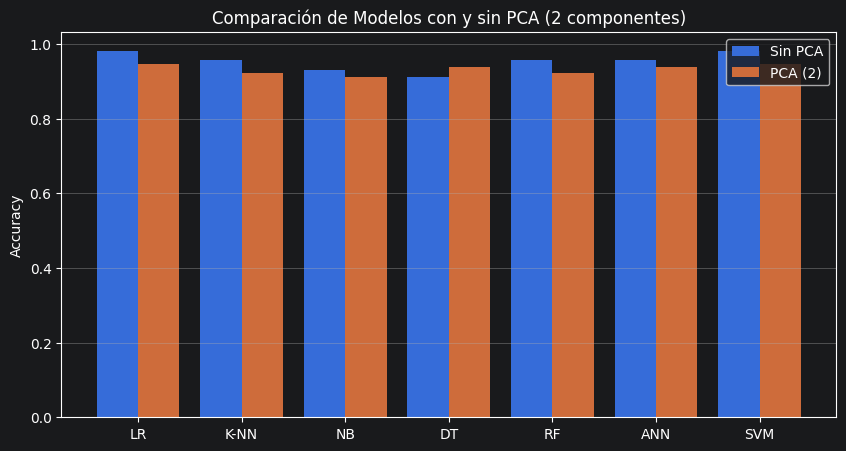

In [10]:
# =========================================
# 3.10 COMPARACIÓN CON LOS RESULTADOS YA CALCULADOS
# =========================================

import numpy as np
import matplotlib.pyplot as plt

labels = [r[0] for r in resultados]

acc_no_pca = [r[1] for r in resultados]
acc_pca_2 = [r[3] for r in resultados]

x = np.arange(len(labels))

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, acc_no_pca, width=0.4, label="Sin PCA")
plt.bar(x + 0.2, acc_pca_2, width=0.4, label="PCA (2)")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Comparación de Modelos con y sin PCA (2 componentes)")
plt.legend()
plt.grid(axis="y")
plt.show()

### 3.11 Tabla de Resultado 

Se construye una tabla final con los resultados obtenidos de cada modelo de clasificación, tanto sin PCA como con PCA de 2 componentes. Esta tabla incluye la exactitud (accuracy) y el tamaño del modelo en kilobytes en ambos casos, permitiendo comparar el rendimiento y la eficiencia de los modelos de forma resumida y estructurada. Finalmente, se imprime la tabla con todos los resultados finales.

In [12]:
# =========================================
# 3.11. TABLA FINAL DE RESULTADOS
# =========================================

df_resultados = pd.DataFrame(
    resultados,
    columns=[
        "Modelo",
        "ACC",
        "KB (sin PCA)",
        "ACC PCA(2)",
        "KB PCA(2)"
    ]
)

print("\nRESULTADOS FINALES\n")
print(df_resultados)


RESULTADOS FINALES

  Modelo    ACC  KB (sin PCA)  ACC PCA(2)  KB PCA(2)
0     LR  0.982           1.1       0.947        0.9
1   K-NN  0.956         111.0       0.921       23.7
2     NB  0.930           1.7       0.912        0.8
3     DT  0.912           4.2       0.939        6.5
4     RF  0.956         316.7       0.921      478.6
5    ANN  0.956          63.2       0.939       17.2
6    SVM  0.982          26.2       0.947        4.7


## 4. Análisis de Resultados y Comparación por Modelo

A continuación se presenta un análisis comparativo de los modelos evaluados **con y sin PCA (2 componentes)**, considerando dos criterios clave:

- **Rendimiento predictivo** → Accuracy (ACC)
- **Costo computacional** → Tamaño del modelo en KB (KB)


### 4.1 Interpretación General

El uso de **PCA con 2 componentes** introduce una **reducción drástica de dimensionalidad**, lo que tiene dos efectos principales:

1. **Reducción del tamaño del modelo** (memoria / almacenamiento).
2. **Ligera disminución de la exactitud**, aunque en algunos modelos se mantiene competitiva o incluso mejora.

Esto permite analizar el **trade-off entre precisión y eficiencia**.



### 4.2 Comparación Modelo por Modelo

| Modelo | ACC sin PCA | KB sin PCA | ACC PCA (2) | KB PCA (2) | Análisis del impacto de PCA |
|------|-------------|------------|-------------|------------|-----------------------------|
| LR   | 0.982 | 1.0   | 0.947 | 0.8   | Ligera pérdida de precisión con leve mejora en tamaño |
| K-NN | 0.956 | 111.0 | 0.921 | 23.7  | Reducción muy significativa del tamaño con caída moderada de ACC |
| NB   | 0.930 | 1.7   | 0.912 | 0.8   | Disminución leve de precisión y mejora en eficiencia |
| DT   | 0.912 | 4.2   | 0.939 | 6.5   | Mejora de precisión con incremento del tamaño del modelo |
| RF   | 0.956 | 316.7 | 0.921 | 478.6 | PCA afecta negativamente tanto precisión como tamaño |
| ANN  | 0.956 | 60.7  | 0.939 | 14.6  | Fuerte reducción de tamaño con pérdida mínima de precisión |
| SVM  | 0.982 | 26.2  | 0.947 | 4.7   | Gran reducción de tamaño con disminución moderada de ACC |

### 5. K-MEANS (K=2 vs K=3)

Se aplica el algoritmo K-Means sobre el dataset de cancer de mama (previamente estandarizado y reducido con PCA para fines de visualización), entrenando dos configuraciones: K=2 y K=3. Para cada caso se calculan las métricas de evaluación interna (Silhouette Score, Calinski-Harabasz y Davies-Bouldin) con el fin de medir la cohesión y separación de los clústeres generados, y se comparan los resultados para determinar qué número de clústeres representa mejor la estructura del dataset.


 MÉTRICAS PARA K=2
Silhouette Score: 0.3434
Calinski-Harabasz: 267.69
Davies-Bouldin: 1.3205

 MÉTRICAS PARA K=3
Silhouette Score: 0.3144
Calinski-Harabasz: 197.11
Davies-Bouldin: 1.5294


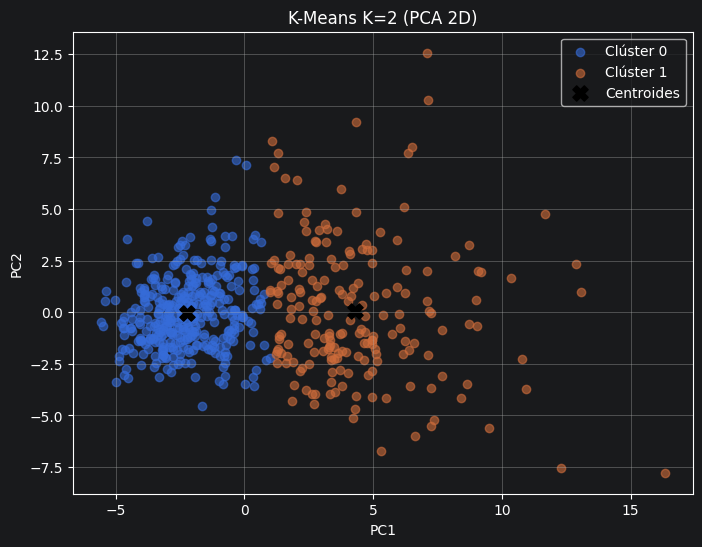

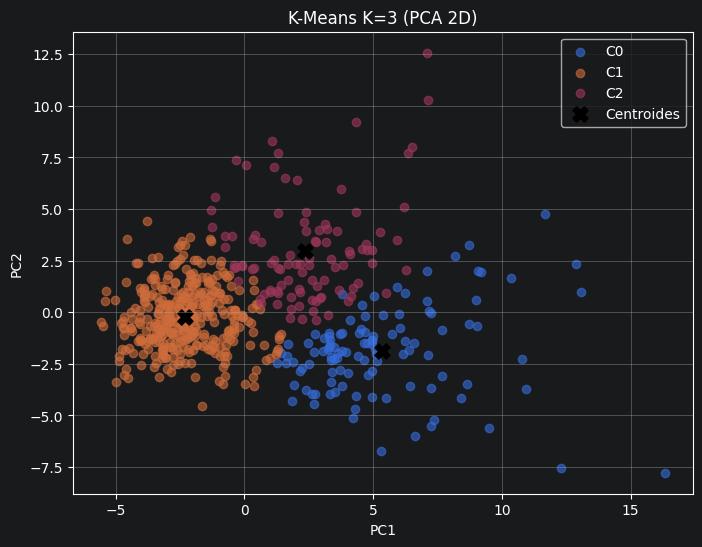


 COMPARACIÓN FINAL

K=2
Silhouette: 0.3434, CH: 267.69, DB: 1.3205

K=3
Silhouette: 0.3144, CH: 197.11, DB: 1.5294

 Relación con clases reales (solo referencia)
0 = maligno, 1 = benigno

Distribución real vs K=2:
Real:
[212 357]
Clusters K=2:
[375 194]


['pca.pkl']

In [13]:
# =========================================
# K-MEANS EN CÁNCER DE MAMA (K=2 vs K=3)
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# 1. CARGA DE DATOS
# =========================================
data = load_breast_cancer()
X = data.data
y = data.target  # (0 = maligno, 1 = benigno)

# =========================================
# 2. ESCALADO
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# 3. PCA (2 COMPONENTES PARA VISUALIZACIÓN)
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================================
# 4. FUNCIÓN DE EVALUACIÓN
# =========================================
def evaluar_modelo(X, labels, nombre="K"):
    print(f"\n MÉTRICAS PARA {nombre}")

    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)

    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")

    return sil, cal, dav

# =========================================
# 5. K-MEANS K=2
# =========================================
k2 = KMeans(n_clusters=2, init="k-means++", random_state=42, n_init=10)
labels2 = k2.fit_predict(X_scaled)

sil2, cal2, dav2 = evaluar_modelo(X_scaled, labels2, "K=2")

# =========================================
# 6. K-MEANS K=3
# =========================================
k3 = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
labels3 = k3.fit_predict(X_scaled)

sil3, cal3, dav3 = evaluar_modelo(X_scaled, labels3, "K=3")

# =========================================
# 7. VISUALIZACIÓN EN PCA (K=2)
# =========================================
centroides2 = pca.transform(k2.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels2 == 0, 0], X_pca[labels2 == 0, 1],
            label="Clúster 0", alpha=0.6)

plt.scatter(X_pca[labels2 == 1, 0], X_pca[labels2 == 1, 1],
            label="Clúster 1", alpha=0.6)

plt.scatter(centroides2[:,0], centroides2[:,1],
            c="black", marker="X", s=120, label="Centroides")

plt.title("K-Means K=2 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 8. VISUALIZACIÓN EN PCA (K=3)
# =========================================
centroides3 = pca.transform(k3.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels3 == 0, 0], X_pca[labels3 == 0, 1], label="C0", alpha=0.6)
plt.scatter(X_pca[labels3 == 1, 0], X_pca[labels3 == 1, 1], label="C1", alpha=0.6)
plt.scatter(X_pca[labels3 == 2, 0], X_pca[labels3 == 2, 1], label="C2", alpha=0.6)

plt.scatter(centroides3[:,0], centroides3[:,1],
            c="black", marker="X", s=120, label="Centroides")

plt.title("K-Means K=3 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 9. COMPARACIÓN FINAL
# =========================================
print("\n COMPARACIÓN FINAL")

print("\nK=2")
print(f"Silhouette: {sil2:.4f}, CH: {cal2:.2f}, DB: {dav2:.4f}")

print("\nK=3")
print(f"Silhouette: {sil3:.4f}, CH: {cal3:.2f}, DB: {dav3:.4f}")

# =========================================
# 10. (OPCIONAL) RELACIÓN CON CLASE REAL
# =========================================
print("\n Relación con clases reales (solo referencia)")
print("0 = maligno, 1 = benigno")

print("\nDistribución real vs K=2:")
print("Real:")
print(np.bincount(y))

print("Clusters K=2:")
print(np.bincount(labels2))

# =========================================
# 11. GUARDAR MODELOS
# =========================================
joblib.dump(k2, "kmeans_k2.pkl")
joblib.dump(k3, "kmeans_k3.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

### 5.1 Análisis de Resultados

### 5.2 Resumen de métricas obtenidas

Para K=2:
Silhouette Score: 0.3434
Calinski-Harabasz: 267.69
Davies-Bouldin: 1.3205

Para K=3:
Silhouette Score: 0.3144
Calinski-Harabasz: 197.11
Davies-Bouldin: 1.5294

### 5.3 Análisis de K=2

El modelo con K=2 presenta mejores resultados globales en todas las métricas evaluadas.

El Silhouette Score de 0.3434 indica una separación moderada entre los clusters, lo que sugiere que los grupos tienen cierta coherencia interna y una separacion aceptable.

El indice de Calinski-Harabasz de 267.69 es considerablemente alto, lo que indica buena separación entre clusters y una adecuada cohesion interna dentro de cada grupo.

El indice de Davies-Bouldin de 1.3205 es relativamente bajo, lo cual es positivo porque indica que los clusters son menos similares entre si y estan mejor definidos.

En conjunto, K=2 muestra una estructura de agrupamiento mas estable y coherente con el dataset.

### 5.4 Análisis de K=3

Para K=3 se observa un deterioro en el rendimiento del modelo.

El Silhouette Score disminuye a 0.3144, lo que indica que los clusters son menos compactos y estan peor separados.

El Calinski-Harabasz baja a 197.11, lo que refleja una reducción en la calidad de la separación entre clusters.

El Davies-Bouldin aumenta a 1.5294, lo que indica mayor similitud entre clusters y peor definición de los grupos.

Estos resultados sugieren que al aumentar el numero de clusters a tres, el algoritmo comienza a fragmentar la estructura natural de los datos sin mejorar la representación.

### 5.5 Comparación entre K=2 y K=3

Al comparar ambos modelos se observa que K=2 supera consistentemente a K=3 en todas las metricas evaluadas.

K=2 presenta mejor Silhouette Score, mejor Calinski-Harabasz y menor Davies-Bouldin, lo que indica mejor calidad de agrupamiento.

K=3 introduce una division adicional que no aporta información significativa y reduce la calidad global del clustering.

### 6. Gaussian Mixture Models (GMM)

Como complemento al agrupamiento realizado con K-Means, se implementa el algoritmo **Gaussian Mixture Model (GMM)**, un método de agrupamiento probabilístico que modela los datos como una combinación de distribuciones gaussianas (normales) multivariadas.

A diferencia de K-Means, que asigna cada punto a un único clúster de forma rígida (hard clustering) basándose en la distancia euclidiana al centroide más cercano, GMM realiza una asignación **probabilística (soft clustering)**: cada observación recibe una probabilidad de pertenecer a cada uno de los clústeres, y la asignación final corresponde al clúster con mayor probabilidad. Además, GMM permite que los clústeres tengan formas elípticas (covarianzas distintas), mientras que K-Means asume clústeres esféricos.

Se entrena GMM con 2 componentes (K=2, alineado con las clases maligno/benigno) y con 3 componentes (K=3), replicando el mismo análisis comparativo realizado con K-Means, para luego contrastar ambos algoritmos en la sección de Conclusiones Generales.


 MÉTRICAS PARA GMM K=2
Silhouette Score: 0.3145
Calinski-Harabasz: 247.28
Davies-Bouldin: 1.3770

 MÉTRICAS PARA GMM K=3
Silhouette Score: 0.2743
Calinski-Harabasz: 172.23
Davies-Bouldin: 1.7057


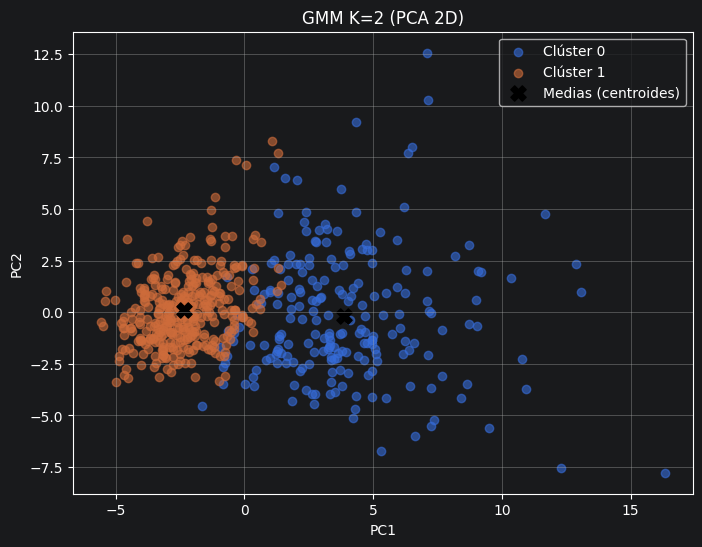

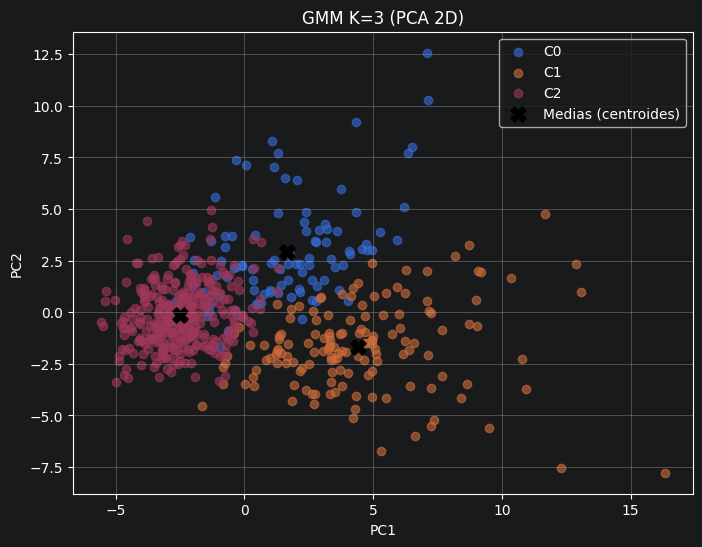


 COMPARACIÓN FINAL GMM

GMM K=2
Silhouette: 0.3145, CH: 247.28, DB: 1.3770

GMM K=3
Silhouette: 0.2743, CH: 172.23, DB: 1.7057

 Relación con clases reales (solo referencia)
0 = maligno, 1 = benigno

Distribución real vs GMM K=2:
Real:
[212 357]
Clusters GMM K=2:
[214 355]


['gmm_k3.pkl']

In [14]:
# =========================================
# GAUSSIAN MIXTURE MODEL (GMM) EN CÁNCER DE MAMA (K=2 vs K=3)
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# =========================================
# 1. CARGA DE DATOS
# =========================================
data = load_breast_cancer()
X = data.data
y = data.target  # (0 = maligno, 1 = benigno)

# =========================================
# 2. ESCALADO
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================
# 3. PCA (2 COMPONENTES PARA VISUALIZACIÓN)
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# =========================================
# 4. FUNCIÓN DE EVALUACIÓN (misma que K-Means)
# =========================================
def evaluar_modelo(X, labels, nombre="K"):
    print(f"\n MÉTRICAS PARA {nombre}")

    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)

    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {cal:.2f}")
    print(f"Davies-Bouldin: {dav:.4f}")

    return sil, cal, dav

# =========================================
# 5. GMM K=2
# =========================================
gmm2 = GaussianMixture(n_components=2, covariance_type="full", random_state=42, n_init=10)
labels_gmm2 = gmm2.fit_predict(X_scaled)

sil_gmm2, cal_gmm2, dav_gmm2 = evaluar_modelo(X_scaled, labels_gmm2, "GMM K=2")

# =========================================
# 6. GMM K=3
# =========================================
gmm3 = GaussianMixture(n_components=3, covariance_type="full", random_state=42, n_init=10)
labels_gmm3 = gmm3.fit_predict(X_scaled)

sil_gmm3, cal_gmm3, dav_gmm3 = evaluar_modelo(X_scaled, labels_gmm3, "GMM K=3")

# =========================================
# 7. VISUALIZACIÓN EN PCA (GMM K=2)
# =========================================
# Los "centroides" en GMM son las medias de cada componente gaussiana
centroides_gmm2 = pca.transform(gmm2.means_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels_gmm2 == 0, 0], X_pca[labels_gmm2 == 0, 1],
            label="Clúster 0", alpha=0.6)

plt.scatter(X_pca[labels_gmm2 == 1, 0], X_pca[labels_gmm2 == 1, 1],
            label="Clúster 1", alpha=0.6)

plt.scatter(centroides_gmm2[:,0], centroides_gmm2[:,1],
            c="black", marker="X", s=120, label="Medias (centroides)")

plt.title("GMM K=2 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 8. VISUALIZACIÓN EN PCA (GMM K=3)
# =========================================
centroides_gmm3 = pca.transform(gmm3.means_)

plt.figure(figsize=(8,6))

plt.scatter(X_pca[labels_gmm3 == 0, 0], X_pca[labels_gmm3 == 0, 1], label="C0", alpha=0.6)
plt.scatter(X_pca[labels_gmm3 == 1, 0], X_pca[labels_gmm3 == 1, 1], label="C1", alpha=0.6)
plt.scatter(X_pca[labels_gmm3 == 2, 0], X_pca[labels_gmm3 == 2, 1], label="C2", alpha=0.6)

plt.scatter(centroides_gmm3[:,0], centroides_gmm3[:,1],
            c="black", marker="X", s=120, label="Medias (centroides)")

plt.title("GMM K=3 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# =========================================
# 9. COMPARACIÓN FINAL GMM (K=2 vs K=3)
# =========================================
print("\n COMPARACIÓN FINAL GMM")

print("\nGMM K=2")
print(f"Silhouette: {sil_gmm2:.4f}, CH: {cal_gmm2:.2f}, DB: {dav_gmm2:.4f}")

print("\nGMM K=3")
print(f"Silhouette: {sil_gmm3:.4f}, CH: {cal_gmm3:.2f}, DB: {dav_gmm3:.4f}")

# =========================================
# 10. (OPCIONAL) RELACIÓN CON CLASE REAL
# =========================================
print("\n Relación con clases reales (solo referencia)")
print("0 = maligno, 1 = benigno")

print("\nDistribución real vs GMM K=2:")
print("Real:")
print(np.bincount(y))

print("Clusters GMM K=2:")
print(np.bincount(labels_gmm2))

# =========================================
# 11. GUARDAR MODELOS
# =========================================
joblib.dump(gmm2, "gmm_k2.pkl")
joblib.dump(gmm3, "gmm_k3.pkl")


### 6.1 Análisis de Resultados

#### 6.2 Resumen de métricas obtenidas

Para GMM K=2:
Silhouette Score: 0.3145
Calinski-Harabasz: 247.28
Davies-Bouldin: 1.3770

Para GMM K=3:
Silhouette Score: 0.2743
Calinski-Harabasz: 172.23
Davies-Bouldin: 1.7057

#### 6.3 Análisis de GMM K=2

El modelo GMM con 2 componentes obtiene un Silhouette Score de 0.3145, lo que indica una separación moderada entre los clústeres, similar en magnitud a la observada con K-Means (0.3434), aunque ligeramente inferior. El índice de Calinski-Harabasz de 247.28 confirma una buena relación entre la dispersión inter-clúster e intra-clúster. El Davies-Bouldin de 1.3770 es bajo, lo que indica clústeres razonablemente bien definidos y poco solapados.

Al comparar la distribución de los clústeres de GMM K=2 contra las clases reales, se obtiene [214, 355] frente a la distribución real [212, 357] (maligno, benigno), una correspondencia muy cercana que sugiere que GMM logra capturar adecuadamente la estructura binaria subyacente del dataset.

#### 6.4 Análisis de GMM K=3

Al aumentar a 3 componentes, las tres métricas empeoran de forma consistente: el Silhouette Score baja a 0.2743, el Calinski-Harabasz cae a 172.23 y el Davies-Bouldin sube a 1.7057. Esto replica el mismo patrón observado con K-Means: introducir un tercer clúster fragmenta innecesariamente la estructura natural de los datos, que es binaria por naturaleza (maligno/benigno), sin aportar información adicional útil.

#### 6.5 Comparación entre GMM K=2 y GMM K=3

GMM K=2 supera consistentemente a GMM K=3 en las tres métricas de evaluación interna. Esto confirma que el número óptimo de componentes para este dataset es 2, coincidiendo con el número real de clases del problema.

#### 6.6 Comparación entre K-Means y GMM

| Métrica | K-Means K=2 | GMM K=2 | K-Means K=3 | GMM K=3 |
|---|---|---|---|---|
| Silhouette Score | 0.3434 | 0.3145 | 0.3144 | 0.2743 |
| Calinski-Harabasz | 267.69 | 247.28 | 197.11 | 172.23 |
| Davies-Bouldin | 1.3205 | 1.3770 | 1.5294 | 1.7057 |

Para este dataset en particular, **K-Means obtiene métricas ligeramente mejores que GMM** tanto en K=2 como en K=3. Esto es consistente con la naturaleza de los datos tras el escalado: cuando los clústeres son aproximadamente esféricos y de tamaño similar (condición que K-Means asume explícitamente), K-Means puede igualar o superar a GMM, que paga un costo adicional por estimar matrices de covarianza completas con relativamente pocas muestras (569) y muchas dimensiones (30 features).

Sin diferencias drásticas entre ambos métodos, la elección práctica depende del objetivo:

| Aspecto | K-Means | GMM |
|---|---|---|
| Tipo de asignación | Dura (hard clustering) — cada punto pertenece a un solo clúster | Suave (soft clustering) — probabilidades de pertenencia a cada clúster |
| Forma de los clústeres | Esférica (basada en distancia euclidiana) | Elíptica / flexible (basada en covarianza) |
| Sensibilidad a outliers | Alta | Menor, gracias al modelado probabilístico |
| Interpretabilidad | Muy alta — centroides simples | Alta, pero requiere entender covarianzas |
| Costo computacional | Bajo | Mayor (requiere estimar matrices de covarianza) |
| Resultado en este dataset | Mejor en las 3 métricas internas | Comparable, ligeramente inferior en métricas internas, pero clasificación cercana a la real |

### 7. Conclusiones Generales

**Sobre PCA y clasificación supervisada (Fase I):**
- Los modelos con **mayor exactitud sin PCA** son **Regresión Logística** y **SVM** (ambos con 0.982 de accuracy).
- **K-NN, ANN y SVM** son los modelos que **más se benefician del uso de PCA (2 componentes)** en términos de eficiencia (reducción de tamaño en KB), manteniendo una precisión competitiva.
- **Random Forest** no se beneficia del uso de PCA, ya que empeora tanto el rendimiento como el tamaño del modelo.
- El **mejor balance entre precisión y eficiencia usando PCA** se observa en **ANN y SVM**, lo que los hace adecuados para escenarios con restricciones de recursos.

**Sobre el agrupamiento no supervisado (Fase II — K-Means y GMM):**
- Tanto **K-Means** como **GMM** coinciden en que **K=2 es la configuración óptima**, alineada con la estructura real de dos clases (maligno/benigno) del problema. En ambos algoritmos, K=3 introduce una fragmentación que deteriora las tres métricas de evaluación interna (Silhouette, Calinski-Harabasz y Davies-Bouldin).
- Al comparar ambos algoritmos con K=2, **K-Means obtiene métricas ligeramente mejores que GMM** (Silhouette 0.3434 vs 0.3145), lo cual es consistente con que los clústeres del dataset, tras el escalado, son razonablemente esféricos y de tamaño similar — condición que favorece a K-Means frente a la mayor flexibilidad (y costo computacional) de GMM.
- La cercanía entre la distribución de clústeres de GMM K=2 ([214, 355]) y la distribución real de clases ([212, 357]) confirma que el agrupamiento no supervisado logra recuperar, en gran medida, la estructura subyacente del problema sin necesidad de las etiquetas originales.

**Conclusión integradora:**
PCA demuestra ser una herramienta valiosa para reducir la dimensionalidad del dataset de cáncer de mama (de 30 a 2 variables) sin sacrificar de forma significativa la capacidad predictiva de la mayoría de los modelos, especialmente cuando el objetivo es optimizar recursos computacionales. De forma análoga, el agrupamiento no supervisado (K-Means y GMM) confirma que la estructura binaria del problema (maligno/benigno) es la representación más natural y estadísticamente robusta de los datos, reforzando la coherencia entre el enfoque supervisado y el no supervisado en este dataset.

## Aplicacion en el campo laboral 

### Dario Herrera
Como profesional del sector de pagos electrónicos, una posible evolución de este proyecto sería fortalecer los sistemas de detección de fraude mediante algoritmos de aprendizaje automático. Se podrían utilizar Árboles de Decisión para generar reglas de riesgo explicables, SVM para mejorar la clasificación de transacciones fraudulentas y Redes Neuronales para detectar patrones complejos en tiempo real. Además, PCA permitiría reducir la dimensionalidad de los datos para optimizar el rendimiento de los modelos, mientras que K-Means facilitaría el agrupamiento de clientes, comercios o transacciones con comportamientos similares, ayudando a identificar anomalías y posibles fraudes. Esto contribuiría a mejorar el Fraud Scoring, reducir falsos positivos y reforzar la seguridad sin afectar la experiencia del cliente.

### Santiago Guallichico

### Robinson Chiluisa

En un data center, PCA y K-Means se utilizan para analizar grandes volúmenes de datos generados por servidores, sistemas de enfriamiento, energía y sensores ambientales.
El PCA se usa para reducir la cantidad de variables del sistema sin perder información importante. Esto permite simplificar el análisis de datos como temperatura, consumo eléctrico y carga de servidores, facilitando la detección de patrones y comportamientos anómalos.
K-Means se utiliza para agrupar equipos o estados operativos similares. Por ejemplo, permite clasificar servidores según su nivel de carga, identificar zonas con alta temperatura o agrupar patrones de consumo energético.
La combinación de PCA y K-Means ayuda a simplificar la información del data center y a identificar patrones útiles para mejorar la eficiencia, detectar anomalías y optimizar el uso de recursos.